# Task 4 â€” Sobel Edge Detection using Cuda across many PNG images

**6CS005 High Performance Computing | Arkhan Shimar**

Each GPU thread calculates one output pixel. RGB is converted to integer luminance, Sobel Gx and Gy are applied with zero padding, and the rounded magnitude is clamped to 255. The output is an opaque grayscale PNG. Multiple input images are processed in order.


## Get the public project files

The exact source revision is pinned so later repository edits cannot silently change these inputs.

In [ ]:
%%bash
set -euo pipefail
mkdir -p /content/hpc_task4
wget --quiet --tries=3 --output-document=/content/hpc_task4.tar.gz https://codeload.github.com/ArkhanShimar/HPC/tar.gz/49c386c2fbcebb8f971a6c3c69e184c623dede38
test -s /content/hpc_task4.tar.gz
tar -xzf /content/hpc_task4.tar.gz -C /content/hpc_task4 --strip-components=1
echo "Project revision: 49c386c2fbcebb8f971a6c3c69e184c623dede38"

In [2]:
%cd /content/hpc_task4/Task4

/content/hpc_task4/Task4


## Runtime details

In [3]:
%%bash
set -euo pipefail
{
date -u
gcc --version | head -1
lscpu | grep -E "Model name|CPU\(s\)|Thread|Core"
nvidia-smi
nvcc --version
} | tee environment.txt

Mon Sep 28 10:23:16 AM UTC 2026
gcc (Ubuntu 13.3.0-6ubuntu2~24.04.1) 13.3.0
CPU(s):                                  2
On-line CPU(s) list:                     0,1
Model name:                              Intel(R) Xeon(R) CPU @ 2.00GHz
Thread(s) per core:                      2
Core(s) per socket:                      1
NUMA node0 CPU(s):                       0,1
Mon Sep 28 10:23:16 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+======

## CUDA source

In [4]:
%%writefile sobel.cu
#include <stdio.h>
#include <stdlib.h>
#include <string.h>
#include <stdint.h>
#include <math.h>
#include <cuda_runtime.h>
extern "C" {
#include "lodepng.h"
}

__device__ int grey(const unsigned char *image, long long x, long long y, unsigned width, unsigned height) {
    if (x < 0 || y < 0 || x >= width || y >= height) return 0; // Zero padding.
    size_t p = ((size_t)y * width + (size_t)x)*4;
    return (77*(int)image[p] + 150*(int)image[p+1] + 29*(int)image[p+2]) >> 8;
}
__global__ void sobel_edges(const unsigned char *input, unsigned char *output, unsigned width, unsigned height) {
    size_t i = (size_t)blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= (size_t)width*height) return;
    long long x = i % width, y = i / width;
    const int gx[9] = {-1,0,1,-2,0,2,-1,0,1};
    const int gy[9] = {-1,-2,-1,0,0,0,1,2,1};
    int sx = 0, sy = 0;
    for (int dy = -1; dy <= 1; ++dy) {
        for (int dx = -1; dx <= 1; ++dx) {
            int value = grey(input, x+dx, y+dy, width, height);
            int k = (dy+1)*3+dx+1; sx += value*gx[k]; sy += value*gy[k];
        }
    }
    int magnitude = (int)(sqrtf((float)(sx*sx+sy*sy)) + 0.5f);
    unsigned char edge = (unsigned char)(magnitude > 255 ? 255 : magnitude);
    output[i*4] = output[i*4+1] = output[i*4+2] = edge;
    output[i*4+3] = 255; // Opaque edge map, including originally transparent pixels.
}
static int checked(cudaError_t code, const char *action) {
    if (code == cudaSuccess) return 1;
    fprintf(stderr, "%s: %s\n", action, cudaGetErrorString(code)); return 0;
}
static int process_image(const char *filename) {
    unsigned char *input = NULL, *output = NULL, *device_in = NULL, *device_out = NULL;
    unsigned width = 0, height = 0, error;
    size_t pixels = 0, bytes = 0, blocks = 0;
    cudaEvent_t start = NULL, stop = NULL; cudaDeviceProp properties;
    int status = 1; float ms = 0;
    const char *base = strrchr(filename, '/'); base = base ? base+1 : filename;
    size_t name_length = strlen(base); char *out_name = NULL;
    if (name_length < 5 || strcmp(base+name_length-4, ".png")) { fprintf(stderr, "Expected a .png filename: %s\n", filename); return 1; }
    out_name = (char *)malloc(name_length+7);
    if (!out_name) return 1;
    memcpy(out_name, base, name_length-4); strcpy(out_name+name_length-4, "_edges.png");
    error = lodepng_decode32_file(&input, &width, &height, filename);
    if (error) { fprintf(stderr, "%s: %s\n", filename, lodepng_error_text(error)); goto cleanup; }
    if (!width || !height || (size_t)width > SIZE_MAX/(size_t)height/4) { fprintf(stderr, "Invalid image dimensions.\n"); goto cleanup; }
    pixels = (size_t)width*height; bytes = pixels*4; blocks = (pixels+255)/256;
    output = (unsigned char *)malloc(bytes);
    if (!output) goto cleanup;
    if (!checked(cudaGetDeviceProperties(&properties, 0), "GPU properties")) goto cleanup;
    if (blocks > (size_t)properties.maxGridSize[0]) { fprintf(stderr, "Image exceeds grid limit.\n"); goto cleanup; }
    if (!checked(cudaMalloc((void **)&device_in, bytes), "Allocate input image") ||
        !checked(cudaMalloc((void **)&device_out, bytes), "Allocate output image") ||
        !checked(cudaMemcpy(device_in, input, bytes, cudaMemcpyHostToDevice), "Copy image") ||
        !checked(cudaEventCreate(&start), "Create start event") ||
        !checked(cudaEventCreate(&stop), "Create stop event") ||
        !checked(cudaEventRecord(start), "Record start")) goto cleanup;
    sobel_edges<<<(unsigned)blocks, 256>>>(device_in, device_out, width, height);
    if (!checked(cudaGetLastError(), "Launch Sobel kernel") ||
        !checked(cudaEventRecord(stop), "Record stop") ||
        !checked(cudaEventSynchronize(stop), "Wait for Sobel kernel") ||
        !checked(cudaEventElapsedTime(&ms, start, stop), "Measure kernel") ||
        !checked(cudaMemcpy(output, device_out, bytes, cudaMemcpyDeviceToHost), "Copy edge map")) goto cleanup;
    error = lodepng_encode32_file(out_name, output, width, height);
    if (error) { fprintf(stderr, "%s: %s\n", out_name, lodepng_error_text(error)); goto cleanup; }
    printf("%s -> %s | %ux%u | %zu blocks x 256 | Kernel %.3f ms\n", filename, out_name, width, height, blocks, ms);
    status = 0;
cleanup:
    if (start && !checked(cudaEventDestroy(start), "Destroy start event")) status = 1;
    if (stop && !checked(cudaEventDestroy(stop), "Destroy stop event")) status = 1;
    if (device_in && !checked(cudaFree(device_in), "Free device input")) status = 1;
    if (device_out && !checked(cudaFree(device_out), "Free device output")) status = 1;
    free(input); free(output); free(out_name); return status;
}
int main(int argc, char **argv) {
    if (argc < 2) { fprintf(stderr, "Usage: %s image1.png [image2.png ...]\n", argv[0]); return 1; }
    // Output names use input basenames. Reject collisions before processing.
    for (int i = 1; i < argc; ++i) for (int j = 1; j < i; ++j) {
        const char *a = strrchr(argv[i], '/'), *b = strrchr(argv[j], '/');
        a = a ? a+1 : argv[i]; b = b ? b+1 : argv[j];
        if (!strcmp(a,b)) { fprintf(stderr, "Duplicate image basename: %s\n", a); return 1; }
    }
    int failed = 0;
    for (int i = 1; i < argc; ++i) failed += process_image(argv[i]) != 0;
    printf("Images completed: %d | Failed: %d\n", argc-1-failed, failed);
    return failed ? 1 : 0;
}


Overwriting sobel.cu


## Compile

In [5]:
%%bash
set -euo pipefail
gcc -O2 -DLODEPNG_NO_COMPILE_CPP -c lodepng.c -o lodepng.o
nvcc -O2 -lineinfo -DLODEPNG_NO_COMPILE_CPP sobel.cu lodepng.o -o sobel

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).


## Run the main example

In [6]:
%%bash
set -euo pipefail
{
./sobel ../data/images/4x4.png ../data/images/6x4.png ../data/images/sobel_target.png ../data/images/colour_ramp.png
} | tee run.log

../data/images/4x4.png -> 4x4_edges.png | 4x4 | 1 blocks x 256 | Kernel 120.388 ms
../data/images/6x4.png -> 6x4_edges.png | 6x4 | 1 blocks x 256 | Kernel 0.015 ms
../data/images/sobel_target.png -> sobel_target_edges.png | 512x512 | 1024 blocks x 256 | Kernel 0.026 ms
../data/images/colour_ramp.png -> colour_ramp_edges.png | 512x512 | 1024 blocks x 256 | Kernel 0.027 ms
Images completed: 4 | Failed: 0


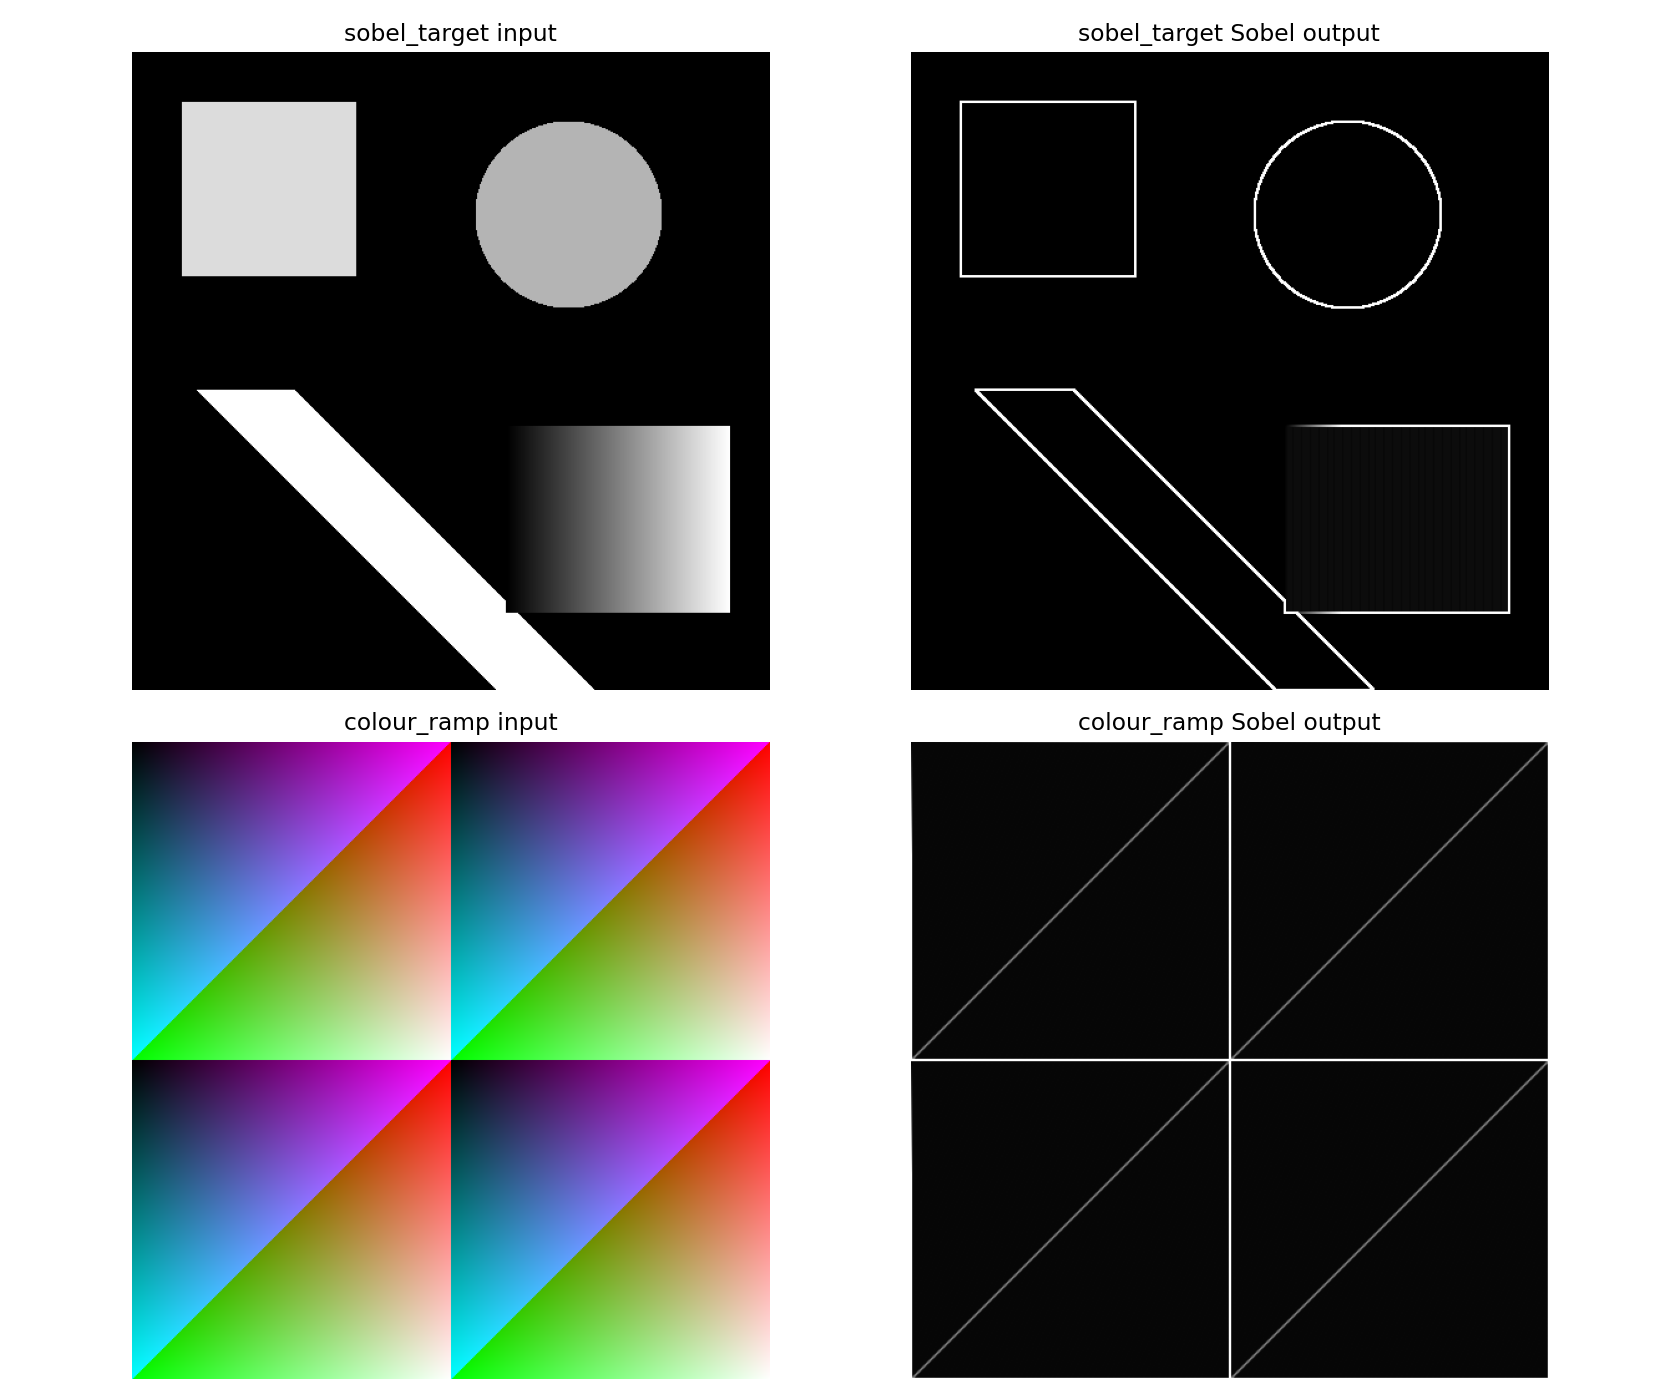

In [7]:
from PIL import Image
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for row, name in enumerate(['sobel_target', 'colour_ramp']):
    for col, path in enumerate([f'../data/images/{name}.png', f'{name}_edges.png']):
        axes[row, col].imshow(Image.open(path).convert('RGB'))
        axes[row, col].set_title(name + (' input' if col == 0 else ' Sobel output'))
        axes[row, col].axis('off')
plt.tight_layout()
plt.savefig('image_comparison.png', dpi=140)
plt.show()

## Correctness checks and measurements

The checks compare against independent CPU references and exercise invalid input. Five measured repeats follow a warm-up where appropriate. CPU timings cover the computation stated by each program; CUDA event timings cover kernels only, not file access, allocation or transfers. These scopes must not be compared as end-to-end speedups.

In [8]:
%%bash
set -euo pipefail
python ../tests/verify.py 4 | tee validation.log

PASS: All four supplied/project images match an independent CPU Sobel reference pixel for pixel
PASS: Zero padding, 1-pixel dimensions, non-multiple block sizes, alpha and widths above 1024
PASS: Corrupt/missing images and duplicate basenames rejected
PASS: Batch continues after a bad image and reports failure

All 4 check groups passed.
{
  "images": 4,
  "comparison": "exact",
  "kernel_ms": [
    0.176,
    0.159,
    0.188,
    0.185,
    0.184
  ],
  "median_kernel_ms": 0.184,
  "demo_log": "/content/hpc_task4/data/images/4x4.png -> 4x4_edges.png | 4x4 | 1 blocks x 256 | Kernel 0.221 ms\n/content/hpc_task4/data/images/6x4.png -> 6x4_edges.png | 6x4 | 1 blocks x 256 | Kernel 0.014 ms\n/content/hpc_task4/data/images/colour_ramp.png -> colour_ramp_edges.png | 512x512 | 1024 blocks x 256 | Kernel 0.026 ms\n/content/hpc_task4/data/images/sobel_target.png -> sobel_target_edges.png | 512x512 | 1024 blocks x 256 | Kernel 0.030 ms\nImages completed: 4 | Failed: 0\n"
}


## Implementation summary

The two 3x3 Sobel masks are evaluated by a single CUDA kernel. Threads use linear pixel indices, with zero padding for neighbours outside the image.


## Output files

The archive contains the output generated by this run and its validation records.


In [ ]:
from pathlib import Path
import shutil, zipfile
from google.colab import files
archive = Path('/content/Task4_outputs.zip')
with zipfile.ZipFile(archive, 'w', zipfile.ZIP_DEFLATED) as z:
    for pattern in ['*.txt', '*.log', '*.png', 'validation/*.json']:
        for path in Path('.').glob(pattern):
            z.write(path, path.as_posix())
files.download(str(archive))